# Анализ городов мира

Установим Folium — библиотеку, с помощью которой можно создавать карты Leaflet:

In [2]:
!pip install folium

Теперь импортируем Folium и другие необходимые для работы библиотеки:

In [3]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
import numpy as np

Перед началом работы с датасетом выведем информацию о нём: размер, названия столбцов и первые пять строк из него:

In [5]:
path = r"worldcities.csv"

df = pd.read_csv(path, encoding="utf-8") # считывание файла в df

print("Размер датасета:", df.shape)
print("\nНазвания столбцов:\n", df.columns.tolist())
print("\nПервые 5 строк:\n", df.head())

Размер датасета: (48059, 11)

Названия столбцов:
 ['city', 'city_ascii', 'lat', 'lng', 'country', 'iso2', 'iso3', 'admin_name', 'capital', 'population', 'id']

Первые 5 строк:
         city city_ascii      lat       lng    country iso2 iso3   admin_name  \
0      Tokyo      Tokyo  35.6870  139.7495      Japan   JP  JPN        Tōkyō   
1    Jakarta    Jakarta  -6.1750  106.8275  Indonesia   ID  IDN      Jakarta   
2      Delhi      Delhi  28.6100   77.2300      India   IN  IND        Delhi   
3  Guangzhou  Guangzhou  23.1300  113.2600      China   CN  CHN    Guangdong   
4     Mumbai     Mumbai  19.0761   72.8775      India   IN  IND  Mahārāshtra   

   capital  population          id  
0  primary  37785000.0  1392685764  
1  primary  33756000.0  1360771077  
2    admin  32226000.0  1356872604  
3    admin  26940000.0  1156237133  
4    admin  24973000.0  1356226629  


*Дисклеймер: видим, что координаты есть положительные и отрицательные. Широта возрастает при движении на север, долгота — при движении на восток, нули — Гринвич и экватор.*

**Теперь перейдём к работе с датасетом!**

# Большие города...

### 🫢10 крупнейших городов

Отразим на барплоте население десяти крупнейших городов:

Text(0, 0.5, 'Население')

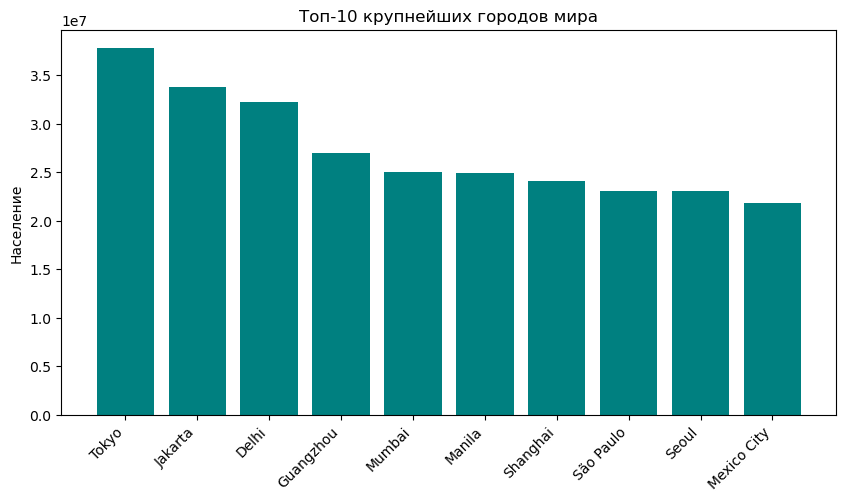

In [38]:
top10 = df.nlargest(10, 'population')
plt.figure(figsize=(10, 5))
plt.bar(top10['city'], top10['population'], color='teal')
plt.xticks(rotation=45, ha='right') # поворот подписей
plt.title("Топ-10 крупнейших городов мира")
plt.ylabel("Население")

Для дальнейшей работы создадим словарь с нужными ключами датасета:

In [6]:
col_map = {}
for c in df.columns:
    lc = c.lower()
    if lc in ('city','city_ascii'):
        col_map['city'] = c
    if lc in ('country'):
        col_map['country'] = c
    if lc in ('population'):
        col_map['population'] = c
    if lc in ('lat'):
        col_map['lat'] = c
    if lc in ('lng'):
        col_map['lng'] = c

**Теперь проанализируем разную информацию из датасета:**

# Большой и ещё крупнее

### 🫣Топ-10 стран по среднему населению городов

Для всех городов по каждой стране рассчитаем среднее население в них и выведем десять стран с самым большим показателем:


Топ-10 стран по среднему населению городов:
country
Singapore               5.983000e+06
China                   7.939591e+05
Kuwait                  7.343922e+05
United Arab Emirates    6.434473e+05
Korea, South            5.974348e+05
Macau                   5.687000e+05
Nigeria                 5.591923e+05
Hong Kong               5.327502e+05
Sudan                   4.353858e+05
Bangladesh              3.878777e+05


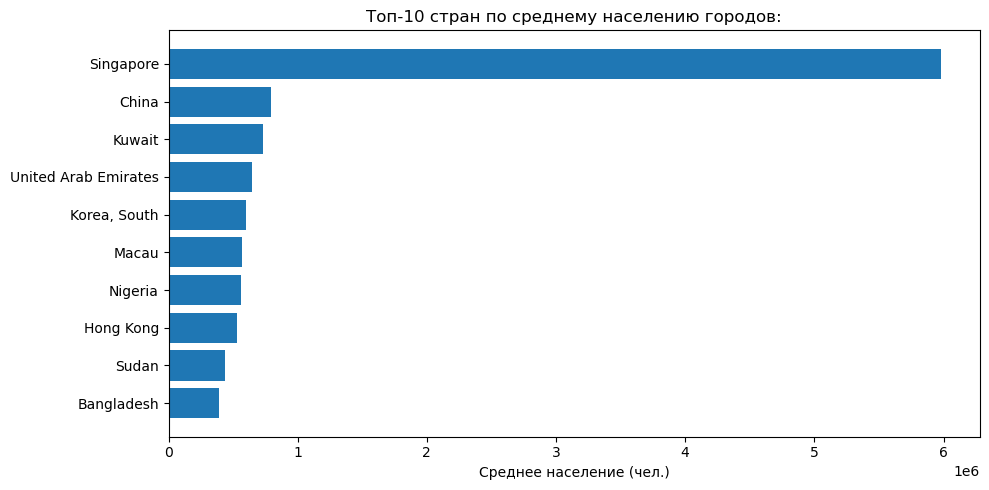

In [14]:
pop_col = col_map['population']
country_col = col_map['country']

df[pop_col] = pd.to_numeric(df[pop_col], errors='coerce') # переводим население в число
pop_notnull = df.dropna(subset=[pop_col, country_col]) # отбрасываем нулевын значения

avg_pop = pop_notnull.groupby(country_col)[pop_col].mean() # группировка по странам и вычисление 
                                                           # среднего населения городов по странам
top10_avg = avg_pop.sort_values(ascending=False).head(10) # 10 самых больших значений
print("\nТоп-10 стран по среднему населению городов:")
print(top10_avg.to_string())

plt.figure(figsize=(10,5))
plt.barh(top10_avg.index[::-1], top10_avg.values[::-1]) # горизонтальный барплот
plt.title("Топ-10 стран по среднему населению городов:")
plt.xlabel("Среднее население (чел.)")
plt.tight_layout()

# 😴Tau­ma­ta­wha­ka­tan­gi­han­ga­ko­au­au­ota­ma­tea­tu­ri­pu­ka­ka­pi­ki­ma­un­ga­ho­ro­nu­ku­po­ka­iwhe­nu­aki­ta­na­ta­hu

### А как распределены длины названий городов? Изучим с помощью барплота:


Медианная длина имени города: 8 символов


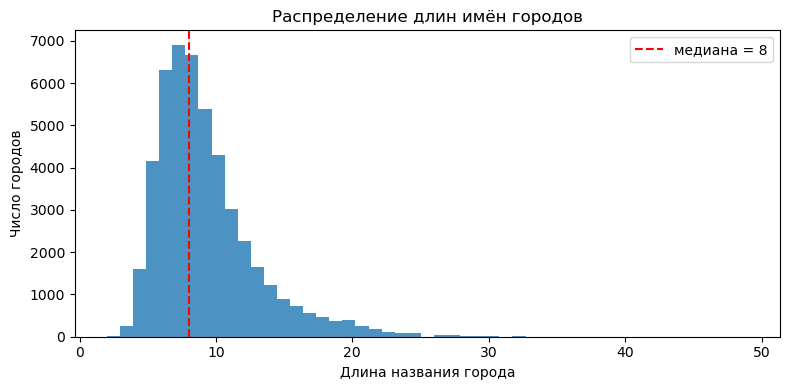

In [7]:
city_col = col_map['city']
df['city_name_len'] = df[city_col].astype(str).str.len()
lens = df['city_name_len'].dropna().astype(int)
median_len = int(lens.median()) # считаем медианную длину названия
print(f"\nМедианная длина имени города: {median_len} символов")

plt.figure(figsize=(8,4))
plt.hist(lens, bins=lens.max(), alpha=0.8)
# создаём горизонтальную линию для медианы
plt.axvline(median_len, color='red', linestyle='--', label=f"медиана = {median_len}")
plt.xlabel("Длина названия города")
plt.ylabel("Число городов")
plt.title("Распределение длин имён городов")
plt.legend()
plt.tight_layout()

# Городов много не бывает

### 🫨Топ 10 стран по количеству городов

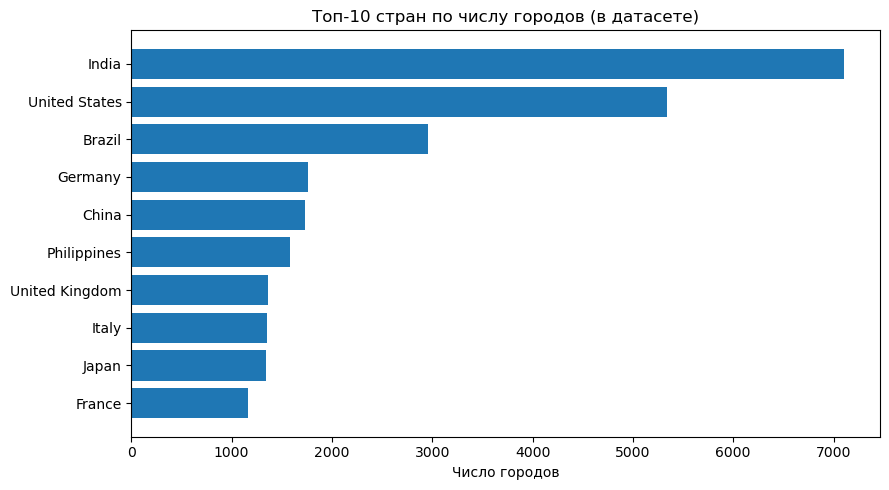

In [30]:
country_col = col_map['country']
lng_col = col_map['lng']
top = df[country_col].value_counts().head(10)
plt.figure(figsize=(9,5))
plt.barh(top.index[::-1], top.values[::-1])
plt.title("Топ-10 стран по числу городов (в датасете)")
plt.xlabel("Число городов")
plt.tight_layout()
plt.show()

# 🏙️ Глобальная карта крупнейших городов мира

💡В данном блоке мы решили попробовать еще более современный способ визуализации данных на карте. Мы нашли информацию о библиотеке Folium, с ее помощью можно работать с интерактивными картами в Python. Такой подход показался нам интересным и визуально красивым.

Визуализация крупнейших городов мира с помощью библиотеки Folium, где размер точки будет зависеть от населения города:

In [8]:
top_cities = df.nlargest(100, 'population') # 100 крупнейших по населению

m = folium.Map(location=[0, 0], zoom_start=2) # создание карты, где параметр location задаёт начальное
                                              # положение обзора, а zoom_start — начальный масштаб

for _, row in top_cities.iterrows(): # берём строчки из топа городов
    folium.CircleMarker( # создаём маркеры на карте
        location=[row['lat'], row['lng']], # задаём координаты
        radius=row['population'] / 1000000,  # задаём радиус маркера, зависящий от населения
        color='crimson',
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['city']}, {row['country']} — {int(row['population']):,} человек" # теперь можно
                                                                # смотреть информацию, нажав на маркер
    ).add_to(m)

m